### <b> probar si un nuevo algoritmo de trading realmente genera rendimientos positivos o si sus ganancias son pura suerte (azar). </b>

In [1]:
import numpy as np
import scipy.stats as stats

# 0. INICIO: Configuración del Escenario
np.random.seed(42)  # Para que los resultados sean replicables

# Parámetros poblacionales simulados
# Simulamos que el algoritmo SÍ es bueno y genera un 0.05% diario (aprox 12.6% anual)
true_mean = 0.0005  
volatility = 0.0120  # Volatilidad diaria del 1.2%
sample_size = 250    # 1 año de datos bursátiles (n > 30, usaremos Z-test)

# Generamos los datos de la muestra (retornos diarios)
retornos_muestra = np.random.normal(true_mean, volatility, sample_size)

# ==========================================
# 1. CONCEPTOS 1 y 2: Hipótesis y Estadístico
# ==========================================
# H0: El algoritmo NO genera valor (Media de retornos = 0)
# H1: El algoritmo SÍ genera valor (Media de retornos > 0) -> Prueba de 1 cola
mu_0 = 0.0000  

# Calculamos los momentos muestrales
media_muestral = np.mean(retornos_muestra)
desviacion_muestral = np.std(retornos_muestra, ddof=1)
error_estandar = desviacion_muestral / np.sqrt(sample_size)

# Calculamos el Estadístico de Prueba (Z-score por el tamaño de muestra)
z_stat = (media_muestral - mu_0) / error_estandar


# 2. DESENLACE: Umbrales y Reglas de Decisión

alpha = 0.05  # Nivel de significancia (Error Tipo I máximo tolerable)

# Método 1: Valor Crítico
valor_critico = stats.norm.ppf(1 - alpha)

# Método 2: Valor p (p-value)
# Al ser de una cola derecha, es 1 menos la probabilidad acumulada
p_value = 1 - stats.norm.cdf(z_stat)


# 3. Intervalo de Confianza y Reporte
#
# Intervalo de confianza del 95% para la media real
conf_level = 0.95
z_critico_dos_colas = stats.norm.ppf(1 - (1 - conf_level)/2)
margen_error = z_critico_dos_colas * error_estandar
intervalo_confianza = (media_muestral - margen_error, media_muestral + margen_error)

# Imprimir el análisis cuantitativo
print(f"--- RESULTADOS DEL ANÁLISIS (MUESTRA DE {sample_size} DÍAS) ---")
print(f"Media Muestral: {media_muestral:.6f} ({media_muestral*100:.4f}%)")
print(f"Error Estándar: {error_estandar:.6f}")
print(f"Estadístico de Prueba (Z): {z_stat:.4f}")
print(f"Valor Crítico (Z alfa): {valor_critico:.4f}")
print(f"Valor p (p-value): {p_value:.4f} ({p_value*100:.2f}%)")
print(f"Intervalo de Confianza 95%: [{intervalo_confianza[0]:.6f}, {intervalo_confianza[1]:.6f}]")
print("-" * 50)

# Conclusión de la historia
if z_stat > valor_critico:
    print("CONCLUSIÓN: RECHAZAMOS la Hipótesis Nula (H0).")
    print("Hay evidencia estadística suficiente para afirmar que el algoritmo genera valor.")
else:
    print("CONCLUSIÓN: FRACASAMOS EN RECHAZAR la Hipótesis Nula (H0).")
    print("No hay evidencia suficiente; los retornos podrían ser producto del azar.")


--- RESULTADOS DEL ANÁLISIS (MUESTRA DE 250 DÍAS) ---
Media Muestral: 0.000471 (0.0471%)
Error Estándar: 0.000733
Estadístico de Prueba (Z): 0.6423
Valor Crítico (Z alfa): 1.6449
Valor p (p-value): 0.2603 (26.03%)
Intervalo de Confianza 95%: [-0.000966, 0.001908]
--------------------------------------------------
CONCLUSIÓN: FRACASAMOS EN RECHAZAR la Hipótesis Nula (H0).
No hay evidencia suficiente; los retornos podrían ser producto del azar.


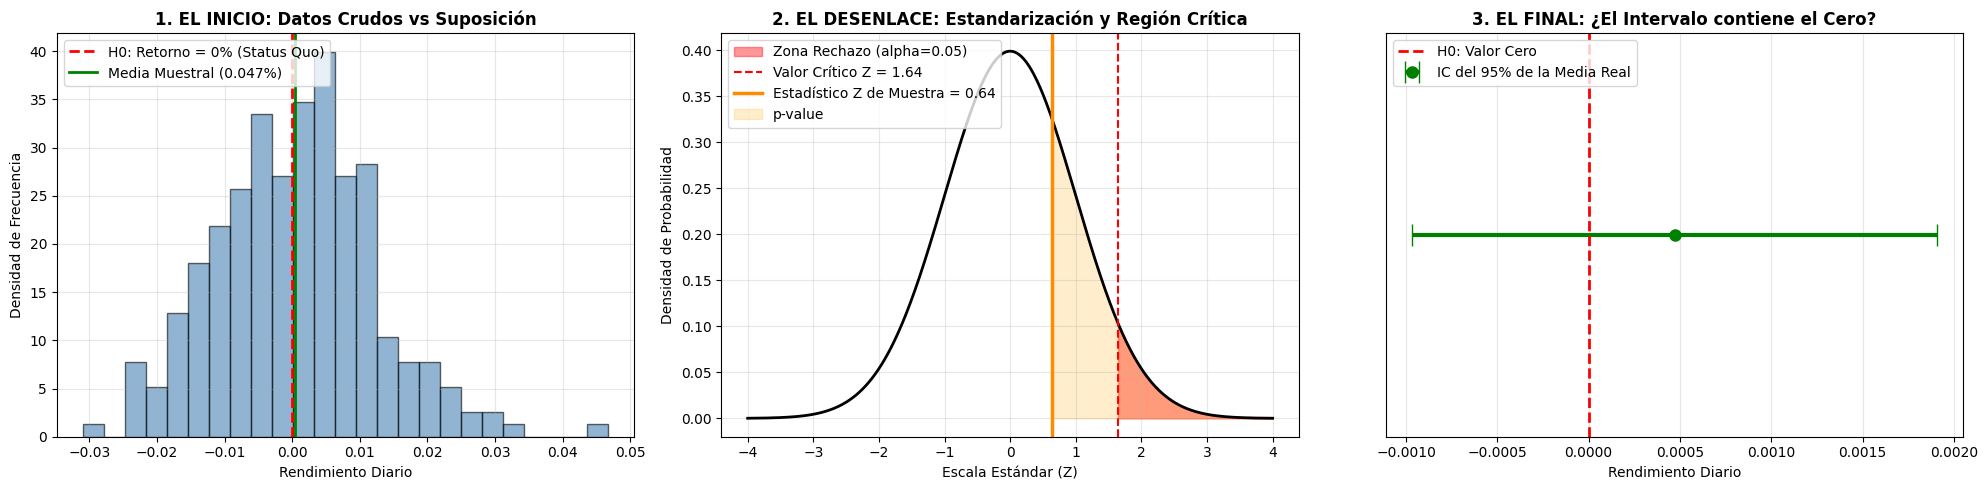

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 0. CONFIGURACIÓN DE DATOS (Mismo escenario)
# ==========================================
np.random.seed(42)
true_mean, volatility, sample_size = 0.0005, 0.0120, 250
retornos_muestra = np.random.normal(true_mean, volatility, sample_size)

# Cálculos estadísticos básicos
media_muestral = np.mean(retornos_muestra)
desviacion_muestral = np.std(retornos_muestra, ddof=1)
error_estandar = desviacion_muestral / np.sqrt(sample_size)

# Parámetros de la prueba (H0: mu = 0)
z_stat = (media_muestral - 0) / error_estandar
alpha = 0.05
valor_critico = stats.norm.ppf(1 - alpha)

# Configurar lienzo de gráficos 
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ==========================================
# GRÁFICO 1: EL INICIO - Datos Crudos vs H0
# ==========================================
ax = axes[0]
ax.hist(retornos_muestra, bins=25, alpha=0.6, color='steelblue', edgecolor='black', density=True)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='H0: Retorno = 0% (Status Quo)')
ax.axvline(media_muestral, color='green', linestyle='-', linewidth=2, label=f'Media Muestral ({media_muestral*100:.3f}%)')
ax.set_title("1. EL INICIO: Datos Crudos vs Suposición", fontsize=12, fontweight='bold')
ax.set_xlabel("Rendimiento Diario")
ax.set_ylabel("Densidad de Frecuencia")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# ==========================================
# GRÁFICO 2: EL DESENLACE - Estadístico, Valor Crítico y p-Value
# ==========================================
ax = axes[1]
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x, 0, 1)
ax.plot(x, y, color='black', linewidth=2)

# Zona de rechazo (Alpha = 5%)
x_rechazo = np.linspace(valor_critico, 4, 100)
ax.fill_between(x_rechazo, stats.norm.pdf(x_rechazo, 0, 1), color='red', alpha=0.4, label=f'Zona Rechazo (alpha={alpha})')

# Líneas del examen FRM
ax.axvline(valor_critico, color='red', linestyle='--', label=f'Valor Crítico Z = {valor_critico:.2f}')
ax.axvline(z_stat, color='darkorange', linestyle='-', linewidth=2.5, label=f'Estadístico Z de Muestra = {z_stat:.2f}')

# Sombrear p-value (área a la derecha de Z observado)
x_p = np.linspace(z_stat, 4, 100)
ax.fill_between(x_p, stats.norm.pdf(x_p, 0, 1), color='orange', alpha=0.2, label='p-value')

ax.set_title("2. EL DESENLACE: Estandarización y Región Crítica", fontsize=12, fontweight='bold')
ax.set_xlabel("Escala Estándar (Z)")
ax.set_ylabel("Densidad de Probabilidad")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# ==========================================
# GRÁFICO 3: EL FINAL - Intervalo de Confianza (95%)
# ==========================================
ax = axes[2]
z_ic = stats.norm.ppf(1 - (1 - 0.95)/2)
margen = z_ic * error_estandar
ic_inf, ic_sup = media_muestral - margen, media_muestral + margen

# Dibujar la línea del intervalo y la media
ax.errorbar(media_muestral, 1, xerr=margen, fmt='o', color='green', markersize=8, capsize=8, linewidth=3, label='IC del 95% de la Media Real')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='H0: Valor Cero')

ax.set_ylim(0.5, 1.5)
ax.set_yticks([])  # Quitar eje Y innecesario
ax.set_title("3. EL FINAL: ¿El Intervalo contiene el Cero?", fontsize=12, fontweight='bold')
ax.set_xlabel("Rendimiento Diario")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Desplegar los tres gráficos
plt.tight_layout()
plt.show()


In [4]:
sample_mu = 0.008  
sample_std = 0.025  
sample_size = 100    
# test statistic 
# (\bar{\mu} - \mu_0 ) / se
se = sample_std / np.sqrt(sample_size) 
z_stat = (sample_mu - 0 ) / se
z_stat

np.float64(3.2)

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
C:\Users\avazq\AppData\Local\Temp\ipykernel_21448\1152257382.py:26: SyntaxWarning: invalid escape sequence '\m'
  label=f'Lo esperado por H0 ($\mu_0$ = {mu_0:.4f})')


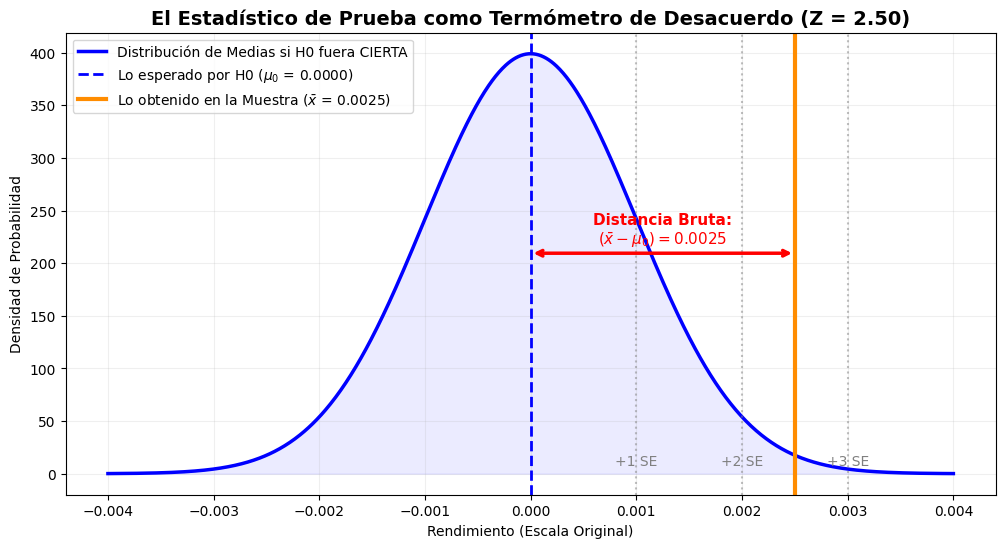

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Configuración del Escenario FRM
# ==========================================
mu_0 = 0.0000          # Teoría (H0): El algoritmo no rinde nada (0%)
media_muestral = 0.0025 # Realidad: La muestra dio 0.25% de rendimiento
se = 0.0010            # Error Estándar (La unidad de medida en el denominador)

# Cálculo del Estadístico de Prueba (Fórmula del examen)
# Z = (Muestra - Teoría) / Regla de Medir
z_stat = (media_muestral - mu_0) / se

# Configurar el espacio para graficar la distribución de H0
x = np.linspace(mu_0 - 4*se, mu_0 + 4*se, 1000)
y = stats.norm.pdf(x, mu_0, se)

# Crear la gráfica
plt.figure(figsize=(12, 6))
plt.plot(x, y, color='blue', linewidth=2.5, label='Distribución de Medias si H0 fuera CIERTA')
plt.fill_between(x, y, color='blue', alpha=0.08)

# Línea de lo que espera H0
plt.axvline(mu_0, color='blue', linestyle='--', linewidth=2, 
            label=f'Lo esperado por H0 ($\mu_0$ = {mu_0:.4f})')

# Línea de lo que realmente obtuviste
plt.axvline(media_muestral, color='darkorange', linestyle='-', linewidth=3, 
            label=f'Lo obtenido en la Muestra ($\\bar{{x}}$ = {media_muestral:.4f})')

# Dibujar la flecha que representa la Distancia (El numerador: \bar{x} - \mu_0)
plt.annotate('', xy=(media_muestral, plt.gca().get_ylim()[1]*0.5), 
             xytext=(mu_0, plt.gca().get_ylim()[1]*0.5),
             arrowprops=dict(arrowstyle="<->", color='red', lw=2.5))

plt.text((mu_0 + media_muestral)/2, plt.gca().get_ylim()[1]*0.52, 
         f'Distancia Bruta:\n$(\\bar{{x}} - \\mu_0) = {media_muestral - mu_0:.4f}$', 
         color='red', fontsize=11, fontweight='bold', ha='center')

# Dibujar los saltos del Error Estándar (Denominador: SE) para ver las "unidades"
for i in range(1, 4):
    plt.axvline(mu_0 + i*se, color='gray', linestyle=':', alpha=0.5)
    plt.text(mu_0 + i*se, plt.gca().get_ylim()[1]*0.02, f'+{i} SE', color='gray', ha='center')

# Títulos y detalles explicativos
plt.title(f"El Estadístico de Prueba como Termómetro de Desacuerdo (Z = {z_stat:.2f})", fontsize=14, fontweight='bold')
plt.xlabel("Rendimiento (Escala Original)")
plt.ylabel("Densidad de Probabilidad")
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.2)

plt.show()


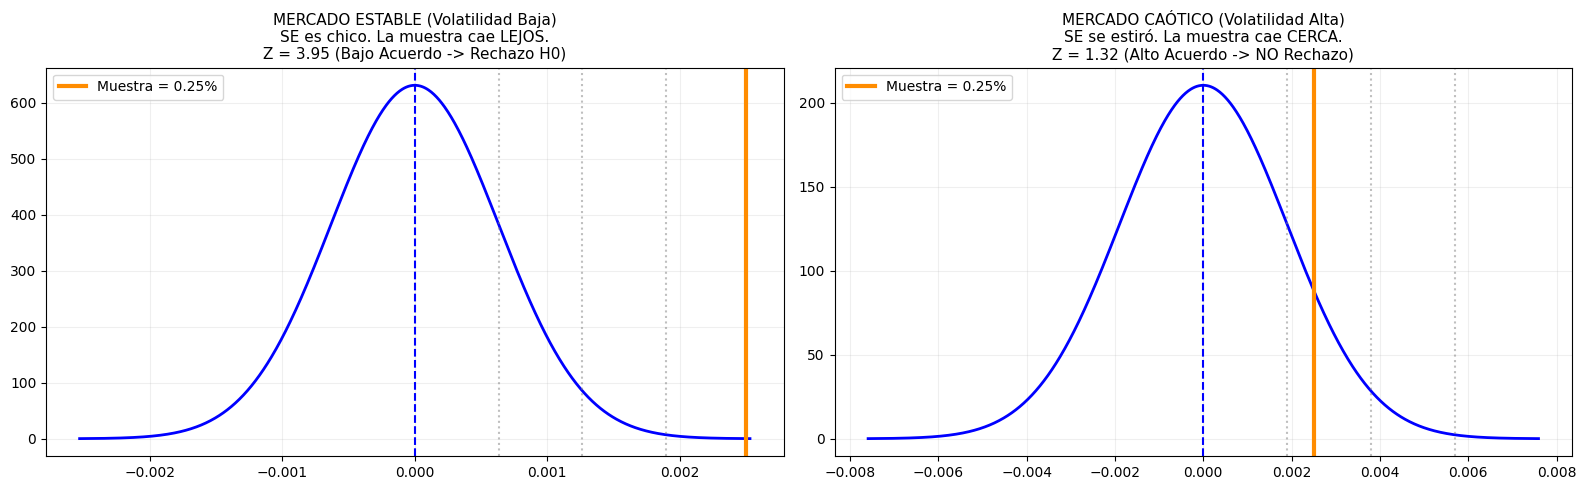

In [2]:
# Parámetros fijos
mu_0 = 0.0000           # Teoría H0: Rendimiento = 0%
media_muestral = 0.0025  # Realidad: El algoritmo rindió 0.25%
sample_size = 250        # Días de muestra

# ESCENARIO 1: Volatilidad Baja (Mercado estable, datos muy concentrados)
vol_baja = 0.0100        # 1.0% de volatilidad diaria
se_baja = vol_baja / np.sqrt(sample_size)
z_baja = (media_muestral - mu_0) / se_baja

# ESCENARIO 2: Volatilidad Alta (Mercado caótico, datos muy dispersos)
vol_alta = 0.0300        # 3.0% de volatilidad diaria (El triple)
se_alta = vol_alta / np.sqrt(sample_size)
z_alta = (media_muestral - mu_0) / se_alta

# Graficar ambos escenarios uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# ---- GRÁFICO izquierda: Volatilidad Baja ----
x1 = np.linspace(mu_0 - 4*se_baja, mu_0 + 4*se_baja, 1000)
axes[0].plot(x1, stats.norm.pdf(x1, mu_0, se_baja), color='blue', lw=2)
axes[0].axvline(mu_0, color='blue', linestyle='--')
axes[0].axvline(media_muestral, color='darkorange', lw=3, label=f'Muestra = {media_muestral*100:.2f}%')
# Dibujar los pasos de SE
for i in range(1, 4):
    axes[0].axvline(mu_0 + i*se_baja, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title(f"MERCADO ESTABLE (Volatilidad Baja)\nSE es chico. La muestra cae LEJOS.\nZ = {z_baja:.2f} (Bajo Acuerdo -> Rechazo H0)", fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.2)

# ---- GRÁFICO derecha: Volatilidad Alta ----
x2 = np.linspace(mu_0 - 4*se_alta, mu_0 + 4*se_alta, 1000)
axes[1].plot(x2, stats.norm.pdf(x2, mu_0, se_alta), color='blue', lw=2)
axes[1].axvline(mu_0, color='blue', linestyle='--')
axes[1].axvline(media_muestral, color='darkorange', lw=3, label=f'Muestra = {media_muestral*100:.2f}%')
# Dibujar los pasos de SE
for i in range(1, 4):
    axes[1].axvline(mu_0 + i*se_alta, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title(f"MERCADO CAÓTICO (Volatilidad Alta)\nSE se estiró. La muestra cae CERCA.\nZ = {z_alta:.2f} (Alto Acuerdo -> NO Rechazo)", fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


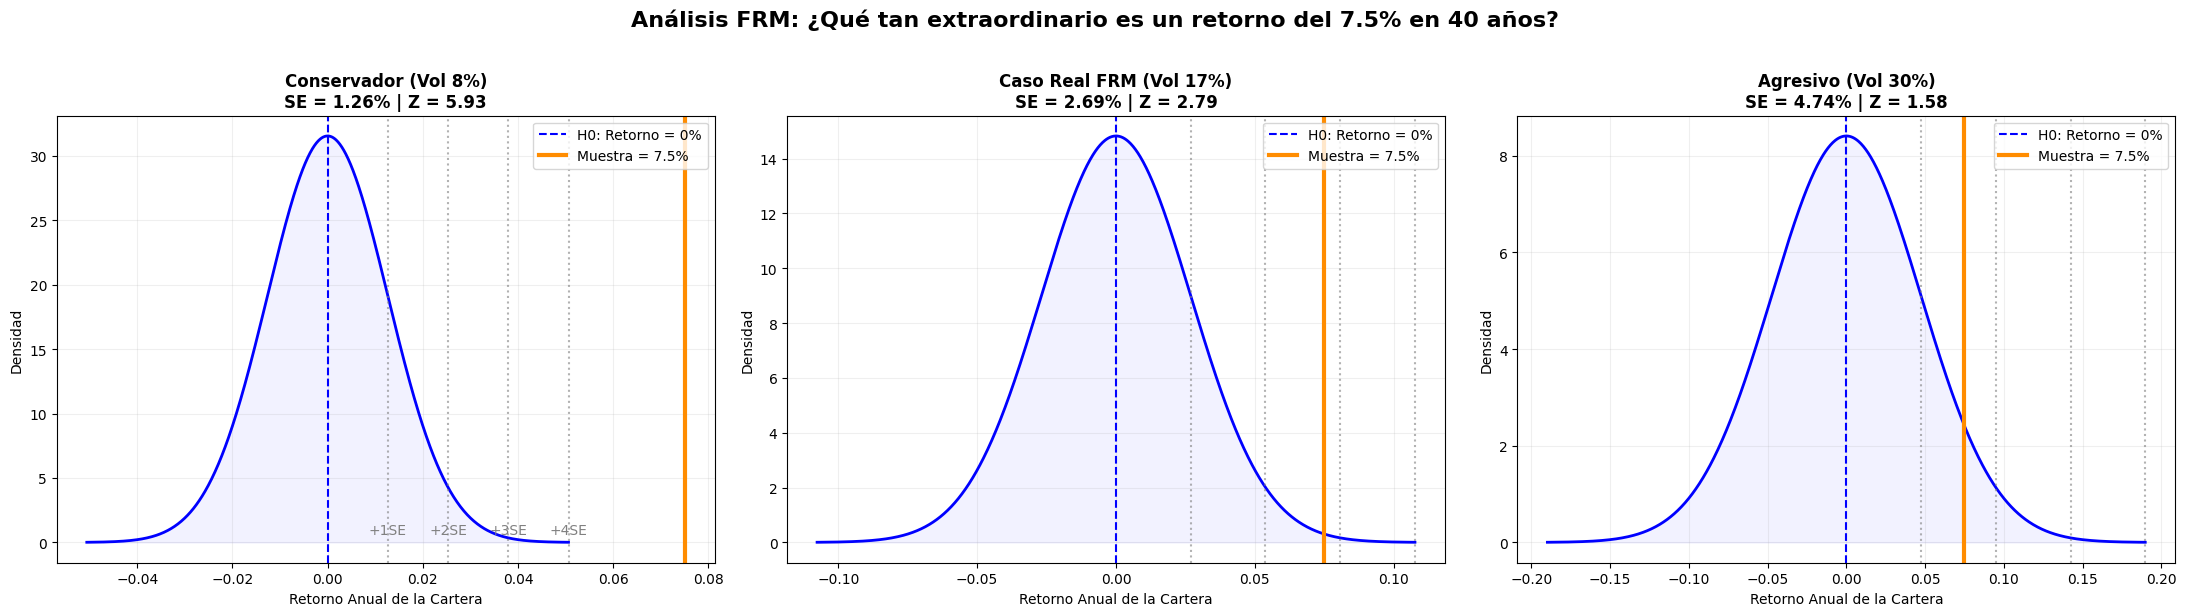

In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Parámetros Fijos del Caso Real FRM
# ==========================================
mu_0 = 0.00         # H0: La cartera no genera retornos reales (0.0%)
media_cartera = 0.075  # Retorno medio reportado (7.5%)
n = 40              # Historial de 40 años

# ==========================================
# CONFIGURACIÓN DE LOS 3 ESCENARIOS DE VOLATILIDAD
# ==========================================
# Escenario 1: El Caso Real (Volatilidad moderada del 17%) -> Z = 2.79
vol_real = 0.17015
se_real = vol_real / np.sqrt(n)
z_real = (media_cartera - mu_0) / se_real

# Escenario 2: Volatilidad Alta (Fondo de Cobertura / Agresivo - 30%)
vol_alta = 0.30
se_alta = vol_alta / np.sqrt(n)
z_alta = (media_cartera - mu_0) / se_alta

# Escenario 3: Volatilidad Baja (Fondo de Pensiones / Conservador - 8%)
vol_baja = 0.08
se_baja = vol_baja / np.sqrt(n)
z_baja = (media_cartera - mu_0) / se_baja

# ==========================================
# CREACIÓN DE LAS GRÁFICAS (3 Escenarios)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=False)
escalas = [("Conservador (Vol 8%)", se_baja, z_baja, 'green'),
           ("Caso Real FRM (Vol 17%)", se_real, z_real, 'orange'),
           ("Agresivo (Vol 30%)", se_alta, z_alta, 'red')]

for i, (nombre, se_actual, z_actual, color) in enumerate(escalas):
    ax = axes[i]
    
    # Dibujar campana de H0
    x = np.linspace(mu_0 - 4*se_actual, mu_0 + 4*se_actual, 1000)
    y = stats.norm.pdf(x, mu_0, se_actual)
    ax.plot(x, y, color='blue', lw=2)
    ax.fill_between(x, y, color='blue', alpha=0.05)
    
    # Líneas de referencia
    ax.axvline(mu_0, color='blue', linestyle='--', label='H0: Retorno = 0%')
    ax.axvline(media_cartera, color='darkorange', lw=3, label=f'Muestra = {media_cartera*100:.1f}%')
    
    # Dibujar las marcas grises de los Error Estándar (La regla de medir)
    for j in range(1, 5):
        ax.axvline(mu_0 + j*se_actual, color='gray', linestyle=':', alpha=0.6)
        if i == 0 and j <= 4: # Para que no se amontone el texto en gráficos apretados
            ax.text(mu_0 + j*se_actual, ax.get_ylim()[1]*0.02, f'+{j}SE', color='gray', ha='center')

    # Títulos e información analítica
    ax.set_title(f"{nombre}\nSE = {se_actual*100:.2f}% | Z = {z_actual:.2f}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Retorno Anual de la Cartera")
    ax.set_ylabel("Densidad")
    ax.grid(alpha=0.2)
    ax.legend(loc='upper right')

plt.suptitle("Análisis FRM: ¿Qué tan extraordinario es un retorno del 7.5% en 40 años?", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


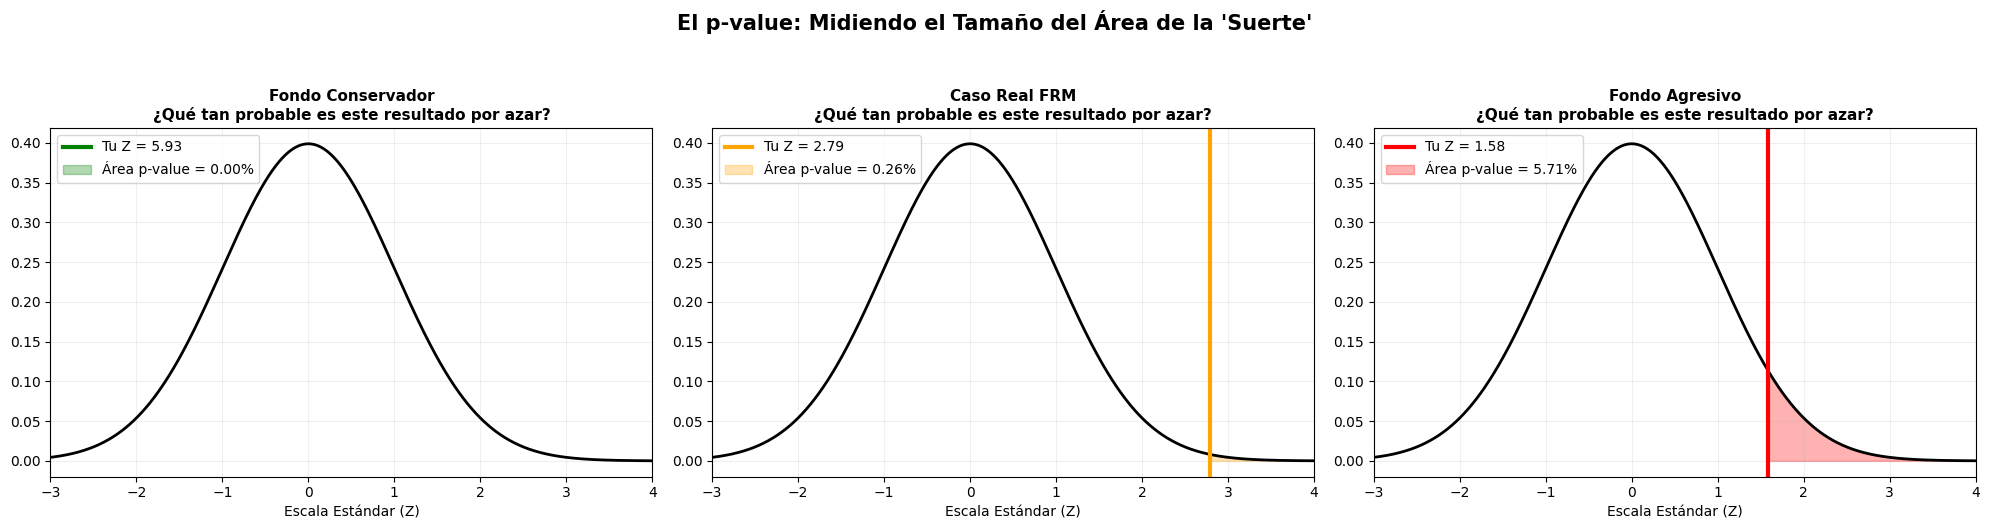

In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Estadísticos Z calculados en el paso anterior
z_conservador = 5.93
z_real = 2.79
z_agresivo = 1.58

# Calcular el p-value para cada uno (Prueba de una cola derecha: 1 - CDF)
p_conservador = 1 - stats.norm.cdf(z_conservador)
p_real = 1 - stats.norm.cdf(z_real)
p_agresivo = 1 - stats.norm.cdf(z_agresivo)

# Configurar gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
escenarios = [
    ("Fondo Conservador", z_conservador, p_conservador, 'green'),
    ("Caso Real FRM", z_real, p_real, 'orange'),
    ("Fondo Agresivo", z_agresivo, p_agresivo, 'red')
]

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

for i, (nombre, z_stat, p_val, color) in enumerate(escenarios):
    ax = axes[i]
    ax.plot(x, y, color='black', lw=2)
    
    # Línea del Estadístico Z de la muestra
    ax.axvline(z_stat, color=color, lw=3, label=f'Tu Z = {z_stat:.2f}')
    
    # Sombrear el p-value (El área a la derecha de nuestra Z)
    # Limitamos visualmente para que se aprecie la sombra
    x_sombra = np.linspace(min(z_stat, 3.9), 4, 500)
    ax.fill_between(x_sombra, stats.norm.pdf(x_sombra, 0, 1), color=color, alpha=0.3, 
                    label=f'Área p-value = {p_val*100:.2f}%')
    
    ax.set_title(f"{nombre}\n¿Qué tan probable es este resultado por azar?", fontsize=11, fontweight='bold')
    ax.set_xlabel("Escala Estándar (Z)")
    ax.set_xlim(-3, 4)
    ax.grid(alpha=0.2)
    ax.legend(loc='upper left')

plt.suptitle("El p-value: Midiendo el Tamaño del Área de la 'Suerte'", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


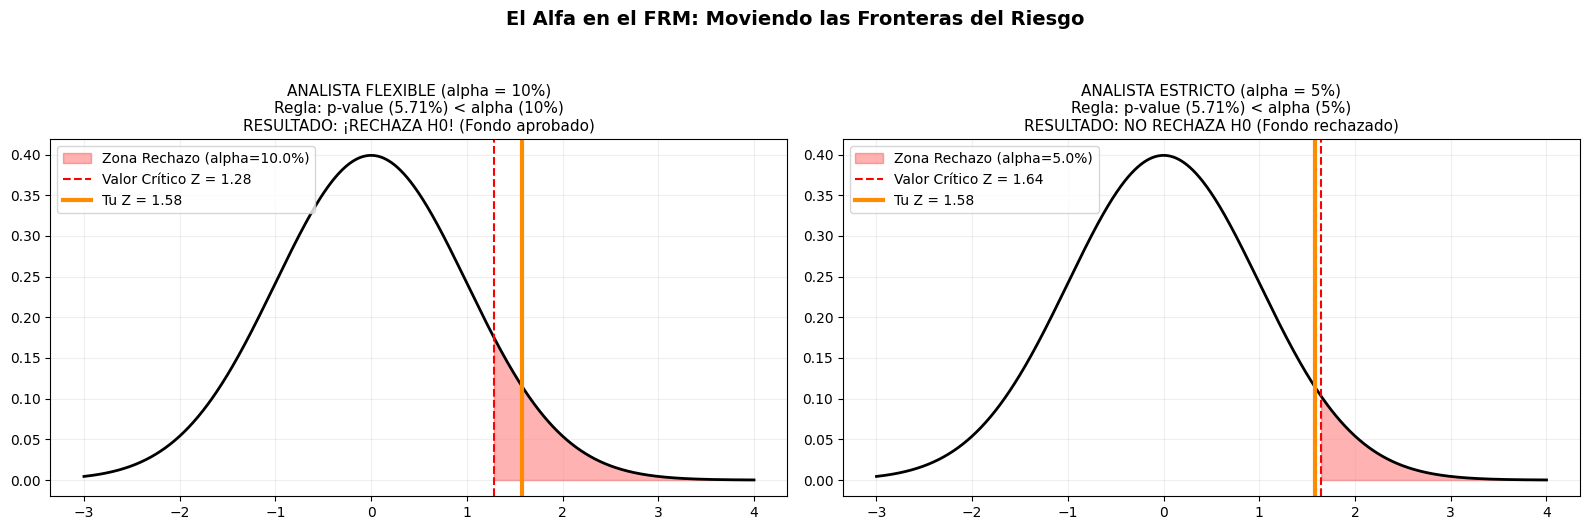

In [5]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Parámetro del fondo agresivo anterior
z_stat = 1.58
p_value = 0.0571

# Dos niveles de rigor diferentes (Alfas)
alpha_flexible = 0.10  # 10% Nivel de significancia (Menos estricto)
alpha_estricto = 0.05  # 5% Nivel de significancia (Estándar/Paranoico)

# Valores críticos para cada alfa (una cola derecha)
critico_flexible = stats.norm.ppf(1 - alpha_flexible)
critico_estricto = stats.norm.ppf(1 - alpha_estricto)

# Configurar gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.linspace(-3, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

# ---- GRÁFICO 1: El Analista Flexible ----
ax = axes[0]
ax.plot(x, y, color='black', lw=2)
# Pintar la zona de rechazo que el analista definió con su alfa
x_rej_flex = np.linspace(critico_flexible, 4, 500)
ax.fill_between(x_rej_flex, stats.norm.pdf(x_rej_flex, 0, 1), color='red', alpha=0.3, label=f'Zona Rechazo (alpha={alpha_flexible*100}%)')
ax.axvline(critico_flexible, color='red', linestyle='--', label=f'Valor Crítico Z = {critico_flexible:.2f}')
ax.axvline(z_stat, color='darkorange', lw=3, label=f'Tu Z = {z_stat:.2f}')

ax.set_title(f"ANALISTA FLEXIBLE (alpha = 10%)\nRegla: p-value ({p_value*100:.2f}%) < alpha (10%)\nRESULTADO: ¡RECHAZA H0! (Fondo aprobado)", fontsize=11)
ax.legend(loc='upper left')
ax.grid(alpha=0.2)

# ---- GRÁFICO 2: El Analista Estricto ----
ax = axes[1]
ax.plot(x, y, color='black', lw=2)
# Pintar la zona de rechazo que el analista definió con su alfa
x_rej_est = np.linspace(critico_estricto, 4, 500)
ax.fill_between(x_rej_est, stats.norm.pdf(x_rej_est, 0, 1), color='red', alpha=0.3, label=f'Zona Rechazo (alpha={alpha_estricto*100}%)')
ax.axvline(critico_estricto, color='red', linestyle='--', label=f'Valor Crítico Z = {critico_estricto:.2f}')
ax.axvline(z_stat, color='darkorange', lw=3, label=f'Tu Z = {z_stat:.2f}')

ax.set_title(f"ANALISTA ESTRICTO (alpha = 5%)\nRegla: p-value ({p_value*100:.2f}%) < alpha (5%)\nRESULTADO: NO RECHAZA H0 (Fondo rechazado)", fontsize=11)
ax.legend(loc='upper left')
ax.grid(alpha=0.2)

plt.suptitle("El Alfa en el FRM: Moviendo las Fronteras del Riesgo", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
C:\Users\avazq\AppData\Local\Temp\ipykernel_21448\3961340099.py:26: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, stats.norm.pdf(x, mu_0, se), color='blue', lw=2, label='Mundo H0: El fondo es malo ($\mu=0$)')
C:\Users\avazq\AppData\Local\Temp\ipykernel_21448\3961340099.py:32: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, stats.norm.pdf(x, mu_1, se), color='green', lw=2, label='Mundo Real H1: El fondo es BUENO ($\mu=2.5$)')


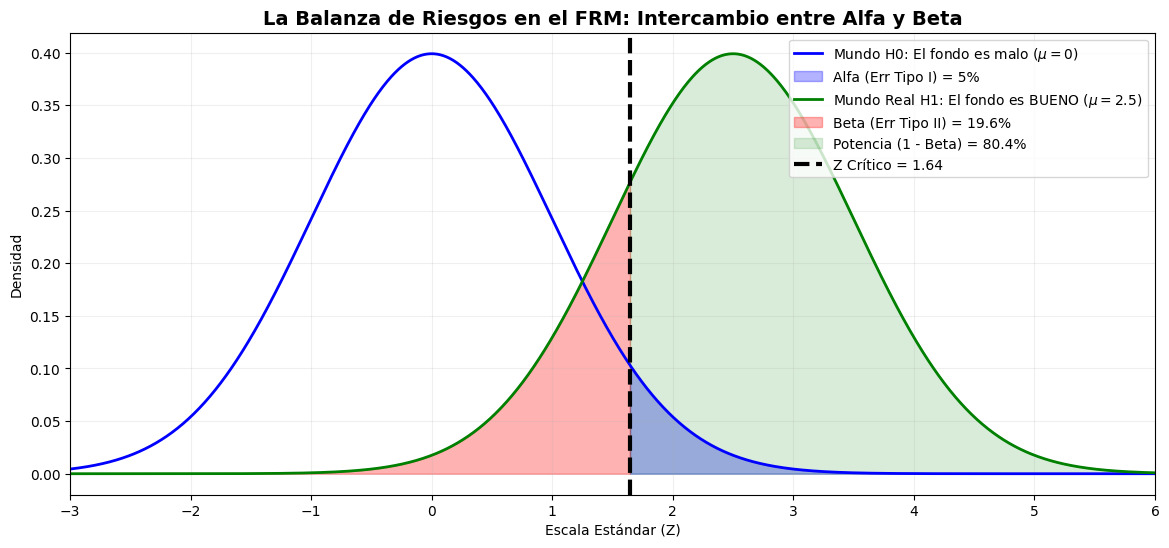

In [6]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Configuramos dos mundos:
# Mundo 1 (Azul): H0 es cierta (Media = 0)
mu_0 = 0
se = 1  # Trabajamos en escala estandarizada Z directamente

# Mundo 2 (Verde): H1 es la verdadera realidad (El fondo SÍ es bueno y su media real Z es 2.5)
mu_1 = 2.5 

# Definimos el Alfa (Rigor del analista)
alpha = 0.05
z_critico = stats.norm.ppf(1 - alpha)  # Esto da 1.64

# Calcular Beta (Error Tipo I: Área de H1 que cae a la izquierda del Z crítico)
beta = stats.norm.cdf(z_critico, loc=mu_1, scale=se)
potencia = 1 - beta

# Graficar las dos realidades enfrentadas
plt.figure(figsize=(14, 6))
x = np.linspace(-3, 6, 1000)

# 1. Curva de la Teoría H0
plt.plot(x, stats.norm.pdf(x, mu_0, se), color='blue', lw=2, label='Mundo H0: El fondo es malo ($\mu=0$)')
# Sombrear Alfa (Error Tipo I)
x_alpha = np.linspace(z_critico, 4, 200)
plt.fill_between(x_alpha, stats.norm.pdf(x_alpha, mu_0, se), color='blue', alpha=0.3, label=f'Alfa (Err Tipo I) = {alpha*100:.0f}%')

# 2. Curva de la Realidad H1
plt.plot(x, stats.norm.pdf(x, mu_1, se), color='green', lw=2, label='Mundo Real H1: El fondo es BUENO ($\mu=2.5$)')
# Sombrear Beta (Error Tipo II)
x_beta = np.linspace(-3, z_critico, 200)
plt.fill_between(x_beta, stats.norm.pdf(x_beta, mu_1, se), color='red', alpha=0.3, label=f'Beta (Err Tipo II) = {beta*100:.1f}%')
# Sombrear Potencia de la Prueba
x_potencia = np.linspace(z_critico, 6, 200)
plt.fill_between(x_potencia, stats.norm.pdf(x_potencia, mu_1, se), color='green', alpha=0.15, label=f'Potencia (1 - Beta) = {potencia*100:.1f}%')

# LA FRONTERA: El Z Crítico
plt.axvline(z_critico, color='black', linestyle='--', lw=3, label=f'Z Crítico = {z_critico:.2f}')

# Detalles
plt.title("La Balanza de Riesgos en el FRM: Intercambio entre Alfa y Beta", fontsize=14, fontweight='bold')
plt.xlabel("Escala Estándar (Z)")
plt.ylabel("Densidad")
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.2)
plt.xlim(-3, 6)

plt.show()


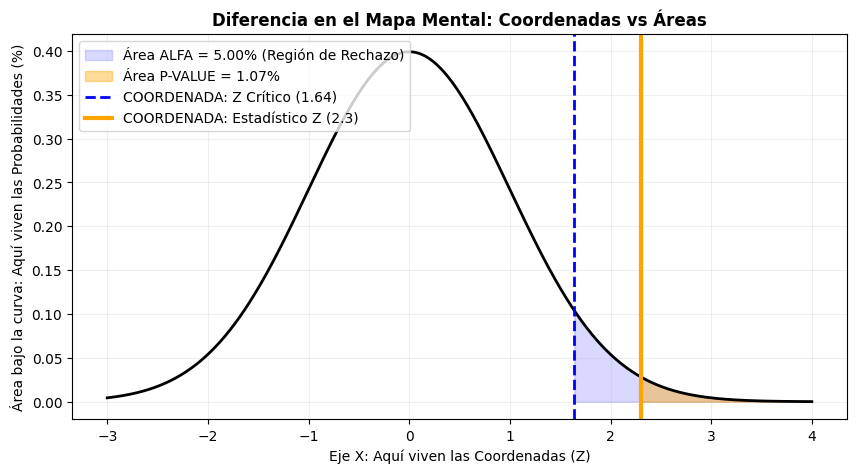

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Configuramos un escenario donde SÍ cruzamos la frontera
z_critico = 1.64   # Coordenada fija (para un alfa del 5%)
z_estadistico = 2.30  # Coordenada de nuestra muestra (¡Cruzó la frontera!)

# Calcular las áreas (p-value)
p_value = 1 - stats.norm.cdf(z_estadistico)

# Graficar
plt.figure(figsize=(10, 5))
x = np.linspace(-3, 4, 1000)
y = stats.norm.pdf(x, 0, 1)
plt.plot(x, y, color='black', lw=2)

# SOMBREAR LAS ÁREAS (Porcentajes)
x_alpha = np.linspace(z_critico, 4, 200)
plt.fill_between(x_alpha, stats.norm.pdf(x_alpha, 0, 1), color='blue', alpha=0.15, 
                 label=f'Área ALFA = 5.00% (Región de Rechazo)')

x_p = np.linspace(z_estadistico, 4, 200)
plt.fill_between(x_p, stats.norm.pdf(x_p, 0, 1), color='orange', alpha=0.4, 
                 label=f'Área P-VALUE = {p_value*100:.2f}%')

# MARCAR LAS COORDENADAS (Puntos en el eje X)
plt.axvline(z_critico, color='blue', linestyle='--', lw=2, label=f'COORDENADA: Z Crítico ({z_critico})')
plt.axvline(z_estadistico, color='orange', linestyle='-', lw=3, label=f'COORDENADA: Estadístico Z ({z_estadistico})')

plt.title("Diferencia en el Mapa Mental: Coordenadas vs Áreas", fontsize=12, fontweight='bold')
plt.xlabel("Eje X: Aquí viven las Coordenadas (Z)")
plt.ylabel("Área bajo la curva: Aquí viven las Probabilidades (%)")
plt.legend(loc='upper left')
plt.grid(alpha=0.2)
plt.show()


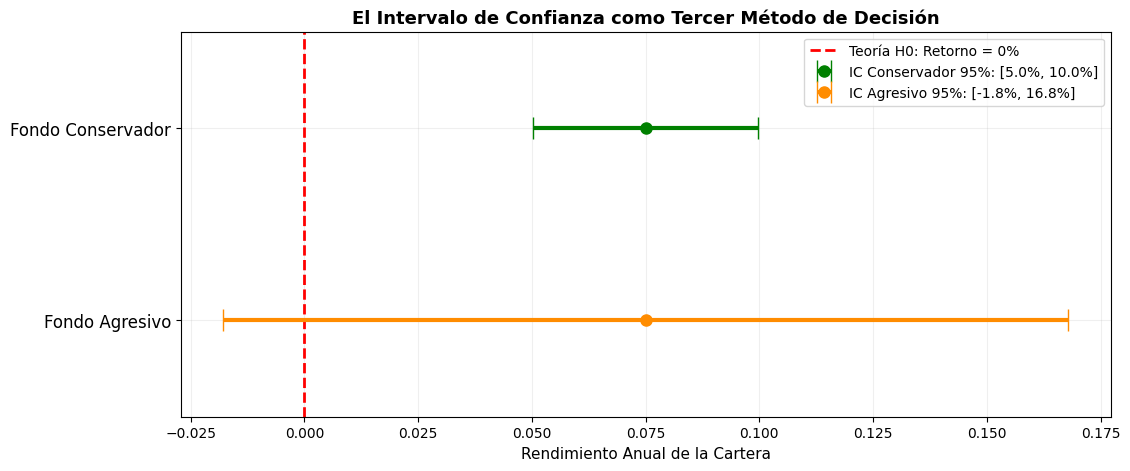

In [2]:
# calcular el Intervalo de Confianza del 95% para la media de la cartera en dos escenarios: 
# el Fondo Conservador (donde rechazamos H_0) y el Fondo Agresivo (donde no pudimos rechazar H_0).

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Parámetros comunes
media_muestra = 0.075  # 7.5% de retorno estimado
mu_0 = 0.00            # El cero de H0
z_critico_2colas = stats.norm.ppf(1 - 0.05/2) # 1.96 (Para un IC del 95%)

# ESCENARIO A: Fondo Conservador (Error estándar chico = 1.26%)
se_conservador = 0.0126
margen_cons = z_critico_2colas * se_conservador
ic_cons = (media_muestra - margen_cons, media_muestra + margen_cons)

# ESCENARIO B: Fondo Agresivo (Error estándar grande = 4.74%)
se_agresivo = 0.0474
margen_agres = z_critico_2colas * se_agresivo
ic_agres = (media_muestra - margen_agres, media_muestra + margen_agres)

# Graficar los intervalos frente al cero de H0
plt.figure(figsize=(12, 5))

# Línea de referencia del Cero (H0)
plt.axvline(mu_0, color='red', linestyle='--', lw=2, label='Teoría H0: Retorno = 0%')

# Dibujar Intervalo Conservador
plt.errorbar(media_muestra, 2, xerr=margen_cons, fmt='o', color='green', 
             markersize=8, capsize=8, lw=3, label=f'IC Conservador 95%: [{ic_cons[0]*100:.1f}%, {ic_cons[1]*100:.1f}%]')

# Dibujar Intervalo Agresivo
plt.errorbar(media_muestra, 1, xerr=margen_agres, fmt='o', color='darkorange', 
             markersize=8, capsize=8, lw=3, label=f'IC Agresivo 95%: [{ic_agres[0]*100:.1f}%, {ic_agres[1]*100:.1f}%]')

# Detalles estéticos
plt.ylim(0.5, 2.5)
plt.yticks([1, 2], ['Fondo Agresivo', 'Fondo Conservador'], fontsize=12)
plt.xlabel("Rendimiento Anual de la Cartera", fontsize=11)
plt.title("El Intervalo de Confianza como Tercer Método de Decisión", fontsize=13, fontweight='bold')
plt.grid(alpha=0.2)
plt.legend(loc='upper right')
plt.show()
